In [1]:
import torch
import torchvision
import seaborn as sns
import numpy as np
import torchmetrics

from torch import nn, optim
from utils import plot_metrics

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
DATA_DIR = 'data'

In [3]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import v2 
from torch.utils.data import DataLoader

transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.5,), std=(0.5,)),
    v2.Lambda(lambda x: torch.flatten(x))
])

train_ds = FashionMNIST(root=DATA_DIR, train=True, transform=transforms, download=True)
test_ds = FashionMNIST(root=DATA_DIR, train=False, transform=transforms, download=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False)

for batch in train_loader:
    imgs, labels = batch
    print(imgs.shape, labels.shape)
    break

torch.Size([64, 784]) torch.Size([64])


In [ ]:
class Classifier(nn.Module):
    def __init__(self, num_features: int, num_labels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_features, 256), # Increased from 128
            nn.ReLU(),
            nn.Linear(256, 128),          # Increased from 32
            nn.ReLU(),
            nn.Linear(128, 128),          # Increased from 32
            nn.ReLU(),
            nn.Linear(128, num_labels)
        )

    def forward(self, x: torch.Tensor):
        return self.net(x)
    
model = Classifier(784, 10).to(device)

In [5]:
optimizer = optim.Adam(model.parameters(), LEARNING_RATE, fused=True)
criterion = nn.CrossEntropyLoss()

metrics = torchmetrics.MetricCollection({
    "accuracy": torchmetrics.Accuracy(task="multiclass", num_classes=10),
    "loss": torchmetrics.MeanMetric()
}).to(device)

metrics_history = {
    'train_loss': [], 'train_accuracy': [],
    'test_loss': [], 'test_accuracy': []
}

In [6]:
def train_step(model: nn.Module, batch: tuple[torch.Tensor, torch.Tensor]):
    x, y = batch[0].to(device), batch[1].to(device)

    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

    metrics.update(preds=logits, target=y, value=loss)


@torch.no_grad()
def eval_step(model: nn.Module, batch: tuple[torch.Tensor, torch.Tensor]):
    model.eval()
    x, y = batch[0].to(device), batch[1].to(device)
    logits = model(x)
    loss = criterion(logits, y)
    metrics.update(preds=logits, target=y, value=loss)
    

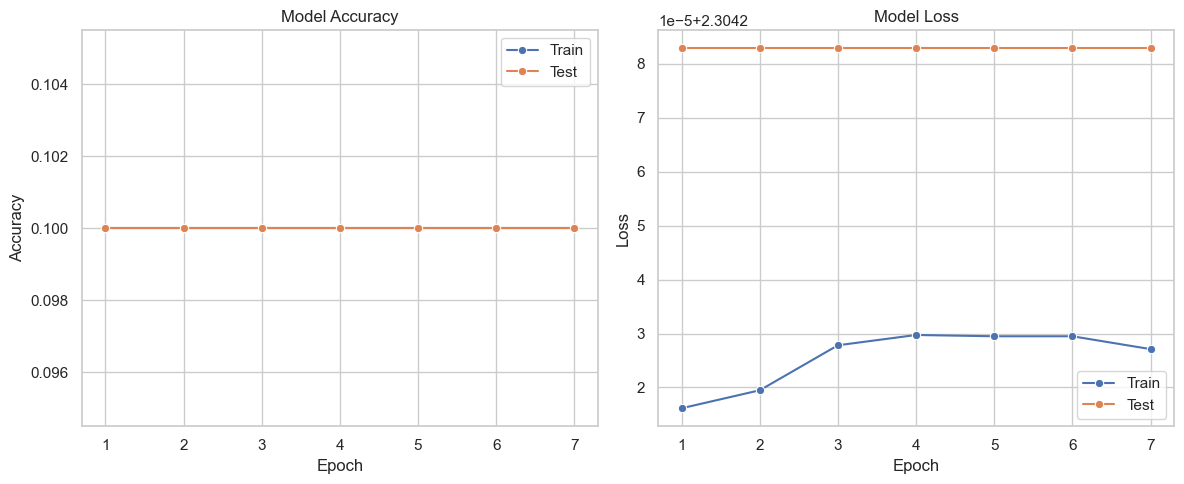

Epoch 7 complete. Test Acc: 0.1000, Test Loss: 2.3043


KeyboardInterrupt: 

In [9]:
for epoch in range(NUM_EPOCHS):
    metrics.reset()
    model.train()
    for batch in train_loader:
        train_step(model, batch)
    
    for metric, value in metrics.compute().items():
        metrics_history[f"train_{metric.lower()}"].append(value.item())

    # --- Evaluation ---
    metrics.reset()
    model.eval()
    for batch in test_loader:
        eval_step(model, batch)
    
    for metric, value in metrics.compute().items():
        metrics_history[f"test_{metric.lower()}"].append(value.item())
    plot_metrics(metrics_history)
    
    latest_acc = metrics_history['test_accuracy'][-1]
    latest_loss = metrics_history['test_loss'][-1]
    print(f"Epoch {epoch+1} complete. Test Acc: {latest_acc:.4f}, Test Loss: {latest_loss:.4f}")